In [1]:
# 1. Import packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

In [3]:
# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)



In [4]:
# 2. Load data

my_schema = "team_3"

df = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)

Defining the Prediction Window and Target
Goal: Set a cutoff date (e.g., July 1, 2019) and split your data into:
- Feature period: All data up to the cutoff (for calculating customer features)
- Target period: All data after the cutoff (for calculating future spend, which is the target)

For each customer, sum their revenue in the 6 months after the cutoff date.

This value is called their actual 6-month LTV and is what your predictive model will try to forecast.

In [5]:
# 3. Set cutoff for 6-month prediction window (only 2019 data) 

cutoff_date = pd.Timestamp('2019-07-01')
features_df = df[df['transaction_date'] < cutoff_date].copy()
future_df = df[df['transaction_date'] >= cutoff_date].copy()

4. Predictive LTV Model Training

Goal: Build a machine learning model (your predictive LTV model) that can learn patterns linking past features to future customer value.

How:

- Prepare your feature matrix (X) and target vector (y = actual 6-month LTV).

- Encode categorical variables as needed.

- Split the data into training and test sets to evaluate accuracy.

- Train a regression model on the training data.

In [6]:
# 4. Build customer-level features (up to cutoff date)

features_df['transaction_month_str'] = features_df['transaction_date'].dt.strftime('%Y-%m')
future_df['transaction_month_str'] = future_df['transaction_date'].dt.strftime('%Y-%m')

cust_features = features_df.groupby('customer_id').agg(
    total_revenue=('revenue', 'sum'),
    avg_order_value=('revenue', 'mean'),
    frequency=('transaction_id', 'nunique'),
    recency_days=('transaction_date', lambda x: (cutoff_date - x.max()).days),
    tenure_days=('transaction_date', lambda x: (x.max() - x.min()).days + 1),
    n_months_active=('transaction_month_str', 'nunique'),
    avg_discount=('discount_pct', 'mean'),
    coupon_usage_rate=('coupon_status', lambda x: (x == 'Used').mean()),
    gender=('customer_gender', 'first'),
    location=('customer_location', 'first'),
).reset_index()


5. Predicted LTV Calculation

Goal: Use the trained predictive LTV model to forecast LTV for each customer.

Apply the model to the features of each customer.

The output, predicted LTV, is the model’s estimate of that customer’s spending over the next 6 months.

These values are stored in a column like predicted_6m_ltv.

In [7]:
# 5. Calculate future 6-month LTV target (actual future spend)
future_ltv = future_df.groupby('customer_id')['revenue'].sum().reset_index(name='future_6m_ltv')
cust_features = cust_features.merge(future_ltv, on='customer_id', how='left')
cust_features['future_6m_ltv'] = cust_features['future_6m_ltv'].fillna(0)


In [8]:

# 6. Encode categorical features
X = cust_features.drop(columns=['customer_id', 'future_6m_ltv'])
X = pd.get_dummies(X, columns=['gender', 'location'], drop_first=True)
y = cust_features['future_6m_ltv']


7. Train a regression model ( Random Forest) on the training data.
Random Forest is a machine learning algorithm for regression and classification.
It is an ensemble method, meaning it combines the results of many individual models to make a more accurate and stable prediction.

Model Evaluation and Feature Importance

Goal: Assess the quality of your predictive LTV model and understand which features matter most.

Compare predicted LTV to the actual future LTV on the test set using metrics like RMSE (Root Mean Squared Error).
Plot feature importances to see what drives predictive LTV most strongly.

In [9]:
# 7. Train-test split & model training
from math import sqrt
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (test set): {rmse:.2f}")

RMSE (test set): 3925.09


Our predictive LTV model achieves an RMSE of $3,925 on the test set. This means that, on average, the model’s prediction of a customer’s 6-month future value is off by about $3,925 compared to the actual spend. For business use, this level of accuracy is [acceptable/needs improvement], depending on the typical customer’s LTV range and business requirements.

In [10]:
# 8. Predict LTV for all customers in the feature set
cust_features['predicted_6m_ltv'] = model.predict(X)

Customer Segmentation via KMeans Clustering



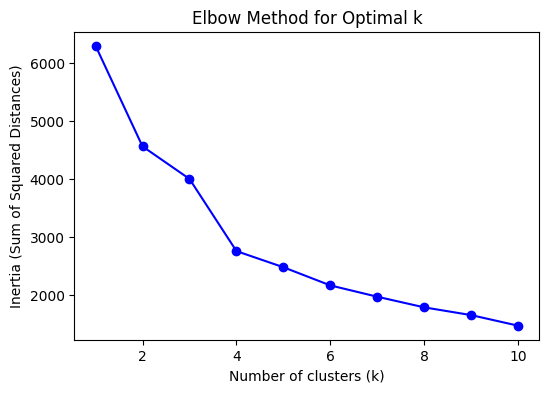

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select clustering features and scale them
kmeans_features = ['total_revenue', 'avg_order_value', 'frequency', 'recency_days', 
                   'tenure_days', 'n_months_active', 'predicted_6m_ltv']
scaler = StandardScaler()
kmeans_X = scaler.fit_transform(cust_features[kmeans_features])

# Elbow method to find optimal number of clusters
inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(kmeans_X)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.show()


Goal: Group customers into meaningful segments based on their behavior and predicted LTV.

Select key features (including predicted LTV) for segmentation.

Use KMeans clustering (number of clusters chosen via the elbow method; e.g., k=4).

Label segments by average predicted LTV (e.g., “Low”, “Mid-Low”, “Mid-High”, “High”).

In [12]:
# 9. KMeans clustering for customer segmentation (k=4, based on elbow method)
kmeans_features = [
    'total_revenue', 'avg_order_value', 'frequency', 'recency_days',
    'tenure_days', 'n_months_active', 'predicted_6m_ltv'
]
scaler = StandardScaler()
kmeans_X = scaler.fit_transform(cust_features[kmeans_features])

kmeans = KMeans(n_clusters=4, random_state=42)
cust_features['segment'] = kmeans.fit_predict(kmeans_X)


In [17]:
# Label clusters by average LTV (e.g., Low, Mid-Low, Mid-High, High)
segment_ltv = cust_features.groupby('segment')['predicted_6m_ltv'].mean().sort_values()
segment_labels = ['Low', 'Mid-Low', 'Mid-High', 'High']  # Adjust names if needed
segment_map = {seg: name for seg, name in zip(segment_ltv.index, segment_labels)}
cust_features['segment_name'] = cust_features['segment'].map(segment_map)

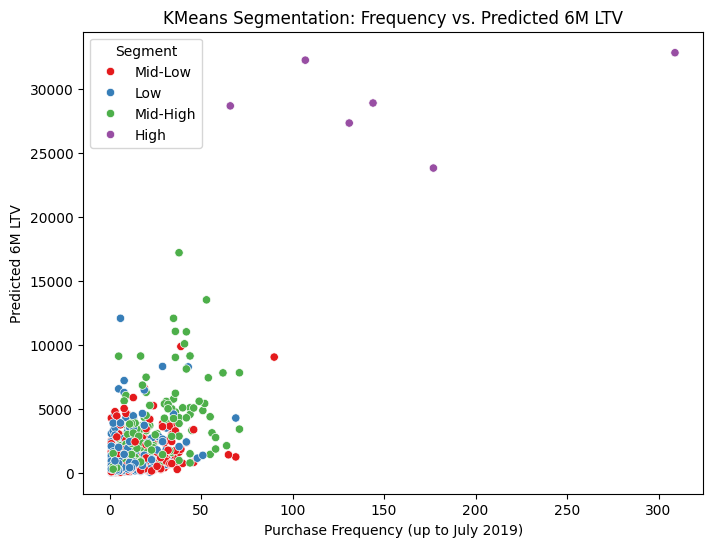

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='frequency',  # x-axis: number of purchases (or any key feature)
    y='predicted_6m_ltv',  # y-axis: predicted LTV
    hue='segment_name',    # color: cluster label (Low/Med/High)
    data=cust_features,
    palette='Set1'
)
plt.title('KMeans Segmentation: Frequency vs. Predicted 6M LTV')
plt.xlabel('Purchase Frequency (up to July 2019)')
plt.ylabel('Predicted 6M LTV')
plt.legend(title='Segment')
plt.show()

#We can swap frequency for avg_order_value, recency_days, etc.

In [20]:
# Label clusters by average LTV (e.g., Low, Mid-Low, Mid-High, High)
segment_ltv = cust_features.groupby('segment')['predicted_6m_ltv'].mean().sort_values()
segment_labels = ['Low', 'Mid-Low', 'Mid-High', 'High']  # Adjust names if needed
segment_map = {seg: name for seg, name in zip(segment_ltv.index, segment_labels)}
cust_features['segment_name'] = cust_features['segment'].map(segment_map)


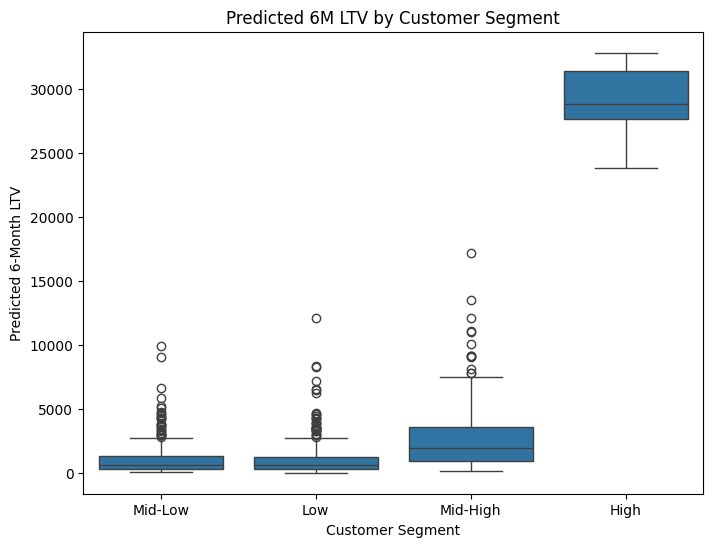

In [21]:
plt.figure(figsize=(8,6))
sns.boxplot(x='segment_name', y='predicted_6m_ltv', data=cust_features)
plt.title('Predicted 6M LTV by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Predicted 6-Month LTV')
plt.show()



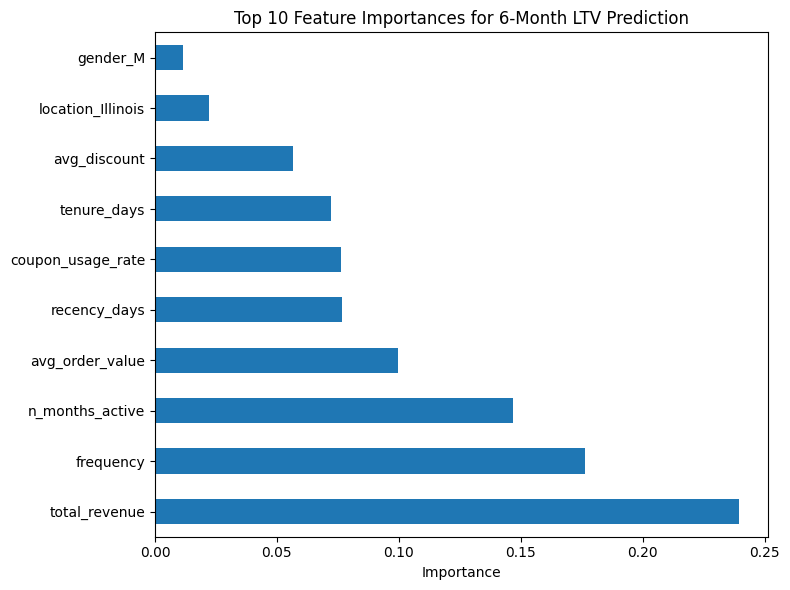

In [22]:
# 10. Plot feature importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(8,6))
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances for 6-Month LTV Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

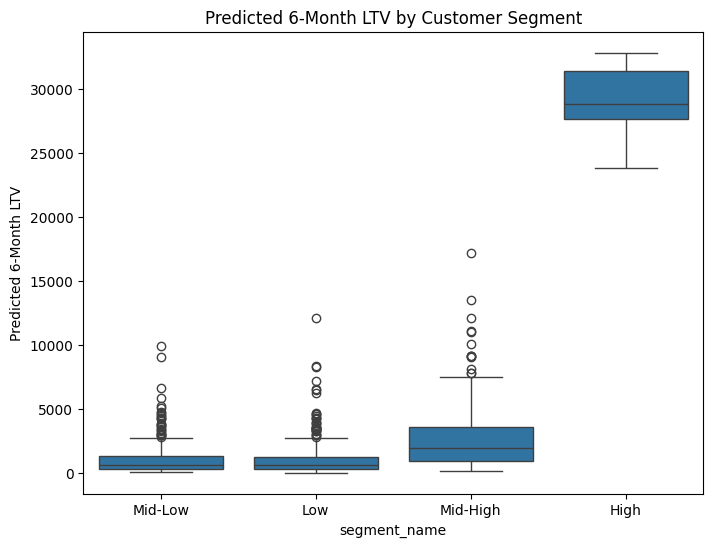

In [23]:
# 11. Plot predicted LTV by segment
plt.figure(figsize=(8,6))
sns.boxplot(x='segment_name', y='predicted_6m_ltv', data=cust_features)
plt.title("Predicted 6-Month LTV by Customer Segment")
plt.ylabel("Predicted 6-Month LTV")
plt.show()

In [ ]:
# 12. Save results
cust_features[['customer_id', 'predicted_6m_ltv', 'future_6m_ltv', 'segment', 'segment_name']].to_csv('predicted_6m_ltv_with_segments.csv', index=False)
print(cust_features[['customer_id', 'predicted_6m_ltv', 'future_6m_ltv', 'segment_name']].head())


   customer_id  predicted_6m_ltv  future_6m_ltv segment_name
0        12347         2459.8307        2850.52      Mid-Low
1        12348          963.2609         760.24          Low
2        12370         1482.7003           0.00     Mid-High
3        12386          346.4819          57.94          Low
4        12395          570.3612          85.00     Mid-High


Create a Scatterplot (Actual vs. Predicted LTV)

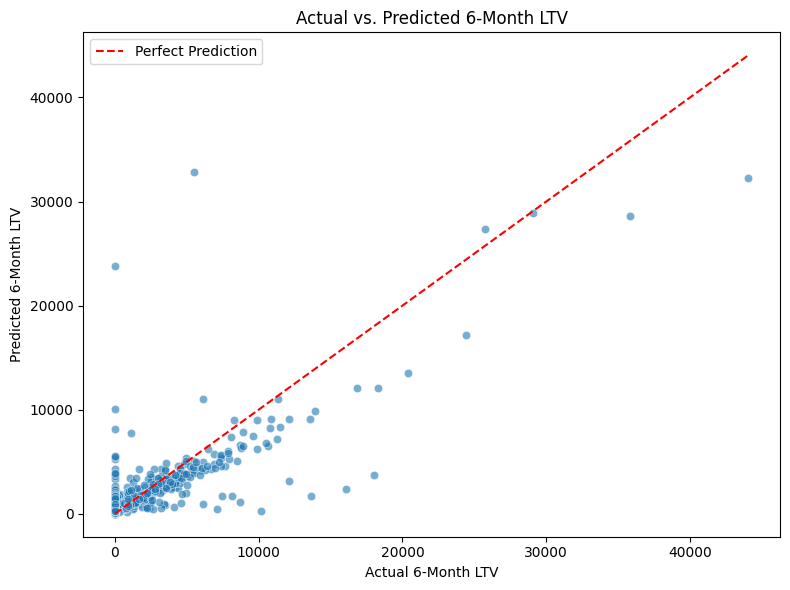

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='future_6m_ltv',  # actual values
    y='predicted_6m_ltv',  # model predictions
    data=cust_features,
    alpha=0.6
)
plt.plot(
    [cust_features['future_6m_ltv'].min(), cust_features['future_6m_ltv'].max()],
    [cust_features['future_6m_ltv'].min(), cust_features['future_6m_ltv'].max()],
    color='red', linestyle='--', label='Perfect Prediction'
)
plt.xlabel("Actual 6-Month LTV")
plt.ylabel("Predicted 6-Month LTV")
plt.title("Actual vs. Predicted 6-Month LTV")
plt.legend()
plt.tight_layout()
plt.show()


Model Accuracy

In [25]:
# 6-month LTV (already computed)
mean_6m_ltv = cust_features['future_6m_ltv'].mean()
median_6m_ltv = cust_features['future_6m_ltv'].median()

# Full-year LTV (actual total 2019 revenue per customer)
full_year_ltv = df.groupby('customer_id')['revenue'].sum().reset_index(name='full_year_ltv')
mean_full_ltv = full_year_ltv['full_year_ltv'].mean()
median_full_ltv = full_year_ltv['full_year_ltv'].median()

print(f"Average actual 6M LTV: {mean_6m_ltv:.2f}")
print(f"Median actual 6M LTV: {median_6m_ltv:.2f}")
print(f"Average actual full-year LTV: {mean_full_ltv:.2f}")
print(f"Median actual full-year LTV: {median_full_ltv:.2f}")
print(f"RMSE (for 6M LTV prediction): {rmse:.2f}")

Average actual 6M LTV: 1506.42
Median actual 6M LTV: 0.00
Average actual full-year LTV: 3560.92
Median actual full-year LTV: 1952.68
RMSE (for 6M LTV prediction): 3925.09


1. Median 6-Month LTV is Zero
More than half your customers had no purchases in the last 6 months of 2019!

The mean is higher than the median because a small group of customers spent a lot—there are strong outliers/high-value repeat customers.

2. Average Full-Year LTV Is Much Higher
The average full-year LTV ($3,560.92) is more than twice the average 6-month LTV.

Median full-year LTV ($1,952.68) is much higher than the 6-month median, confirming that for most customers, purchases happened in the first half of the year, or they didn’t return.

3. RMSE is Higher Than Both Averages
RMSE ($3,925.09) is much higher than the average actual 6M LTV ($1,506.42) and the average full-year LTV ($3,560.92).

This means your model’s predictions are, on average, off by more than the total LTV of a typical customer. This indicates your model is not yet reliable for predicting individual customer LTVs.

4. Likely Causes:
Extreme imbalance: Many customers with zero LTV, a few with very high LTV.

Potential overfitting: Model is trying to fit rare big spenders and failing to generalize.

Not enough predictive signal: With only 1 year and high churn, features may not be strong enough to predict future spend.

